# Healthcare Analytics Platform — Azure Databricks Capstone
## Setup: Create all data files in DBFS

In [0]:
import json

patients_data = """patient_id,patient_name,city,state,age,gender,insurance_status
P101,Rahul Sharma,Hyderabad,Telangana,35,Male,Active
P102,Priya Reddy,Bangalore,Karnataka,29,Female,Active
P103,Amit Kumar,Mumbai,Maharashtra,42,Male,Inactive
P104,Sneha Patel,Delhi,Delhi,31,Female,Active
P105,Farhan Ali,Chennai,Tamil Nadu,55,Male,Active
P106,Neha Singh,Pune,Maharashtra,38,Female,Inactive
P107,Arjun Verma,Hyderabad,Telangana,26,Male,Active
P108,Meera Nair,Kochi,Kerala,48,Female,Active"""

doctors_data = """doctor_id,doctor_name,department,city,consultation_fee
D101,Dr. Ramesh,Cardiology,Hyderabad,1500
D102,Dr. Priya,Neurology,Bangalore,2000
D103,Dr. Anita,Dermatology,Chennai,1000
D104,Dr. Suresh,Orthopedics,Mumbai,2500
D105,Dr. Meera,Pediatrics,Delhi,1200
D106,Dr. Kiran,Cardiology,Hyderabad,3000"""

appointments_data = """appointment_id,patient_id,doctor_id,appointment_date,diagnosis,bill_amount,status
A1001,P101,D101,2026-06-01,Heart Checkup,5000,Completed
A1002,P102,D102,2026-06-01,Migraine,3500,Completed
A1003,P103,D103,2026-06-02,Skin Allergy,2000,Pending
A1004,P104,D104,2026-06-02,Fracture,12000,Completed
A1005,P105,D105,2026-06-03,Fever,1500,Completed
A1006,P106,D106,2026-06-03,Heart Checkup,7000,Completed
A1007,P107,D101,2026-06-04,Chest Pain,5500,Completed
A1008,P108,D103,2026-06-04,Skin Infection,2500,Pending
A1009,P101,D106,2026-06-05,Cardiac Review,6500,Completed
A1010,P104,D104,2026-06-05,Back Pain,4500,Cancelled"""

preferences_data = json.dumps([
    {"patient_id": "P101", "preferred_hospital": "Apollo Hospital", "contact": {"phone": "9876500011", "email": "rahul@mail.com"}},
    {"patient_id": "P102", "preferred_hospital": "Yashoda Hospital", "contact": {"phone": "9876500012", "email": "priya@mail.com"}},
    {"patient_id": "P104", "preferred_hospital": "Care Hospital", "contact": {"phone": "9876500014", "email": "sneha@mail.com"}},
    {"patient_id": "P108", "preferred_hospital": "Apollo Hospital", "contact": {"phone": "9876500018", "email": "meera@mail.com"}}
])

dbutils.fs.put('/FileStore/healthcare/patients.csv', patients_data, overwrite=True)
dbutils.fs.put('/FileStore/healthcare/doctors.csv', doctors_data, overwrite=True)
dbutils.fs.put('/FileStore/healthcare/appointments.csv', appointments_data, overwrite=True)
dbutils.fs.put('/FileStore/healthcare/patient_preferences.json', preferences_data, overwrite=True)
print('All files created in DBFS!')


Wrote 467 bytes.
Wrote 294 bytes.
Wrote 614 bytes.
Wrote 511 bytes.
All files created in DBFS!


## Part 1: Data Ingestion

In [0]:
#2 - Read patients.csv
df_patients = spark.read.csv('/FileStore/healthcare/patients.csv', header=True, inferSchema=True)
display(df_patients)


patient_id,patient_name,city,state,age,gender,insurance_status
P101,Rahul Sharma,Hyderabad,Telangana,35,Male,Active
P102,Priya Reddy,Bangalore,Karnataka,29,Female,Active
P103,Amit Kumar,Mumbai,Maharashtra,42,Male,Inactive
P104,Sneha Patel,Delhi,Delhi,31,Female,Active
P105,Farhan Ali,Chennai,Tamil Nadu,55,Male,Active
P106,Neha Singh,Pune,Maharashtra,38,Female,Inactive
P107,Arjun Verma,Hyderabad,Telangana,26,Male,Active
P108,Meera Nair,Kochi,Kerala,48,Female,Active


In [0]:
#3 - Read doctors.csv
df_doctors = spark.read.csv('/FileStore/healthcare/doctors.csv', header=True, inferSchema=True)
display(df_doctors)


doctor_id,doctor_name,department,city,consultation_fee
D101,Dr. Ramesh,Cardiology,Hyderabad,1500
D102,Dr. Priya,Neurology,Bangalore,2000
D103,Dr. Anita,Dermatology,Chennai,1000
D104,Dr. Suresh,Orthopedics,Mumbai,2500
D105,Dr. Meera,Pediatrics,Delhi,1200
D106,Dr. Kiran,Cardiology,Hyderabad,3000


In [0]:
#4 - Read appointments.csv
df_appointments = spark.read.csv('/FileStore/healthcare/appointments.csv', header=True, inferSchema=True)
display(df_appointments)


appointment_id,patient_id,doctor_id,appointment_date,diagnosis,bill_amount,status
A1001,P101,D101,2026-06-01,Heart Checkup,5000,Completed
A1002,P102,D102,2026-06-01,Migraine,3500,Completed
A1003,P103,D103,2026-06-02,Skin Allergy,2000,Pending
A1004,P104,D104,2026-06-02,Fracture,12000,Completed
A1005,P105,D105,2026-06-03,Fever,1500,Completed
A1006,P106,D106,2026-06-03,Heart Checkup,7000,Completed
A1007,P107,D101,2026-06-04,Chest Pain,5500,Completed
A1008,P108,D103,2026-06-04,Skin Infection,2500,Pending
A1009,P101,D106,2026-06-05,Cardiac Review,6500,Completed
A1010,P104,D104,2026-06-05,Back Pain,4500,Cancelled


In [0]:
#5 - Read patient_preferences.json
df_prefs_raw = spark.read.option('multiline', 'true').json('/FileStore/healthcare/patient_preferences.json')
display(df_prefs_raw)


contact,patient_id,preferred_hospital
"List(rahul@mail.com, 9876500011)",P101,Apollo Hospital
"List(priya@mail.com, 9876500012)",P102,Yashoda Hospital
"List(sneha@mail.com, 9876500014)",P104,Care Hospital
"List(meera@mail.com, 9876500018)",P108,Apollo Hospital


In [0]:
#6 - Display schema of all datasets
print('patients schema:')
df_patients.printSchema()
print('doctors schema:')
df_doctors.printSchema()
print('appointments schema:')
df_appointments.printSchema()
print('preferences schema:')
df_prefs_raw.printSchema()


patients schema:
root
 |-- patient_id: string (nullable = true)
 |-- patient_name: string (nullable = true)
 |-- city: string (nullable = true)
 |-- state: string (nullable = true)
 |-- age: integer (nullable = true)
 |-- gender: string (nullable = true)
 |-- insurance_status: string (nullable = true)

doctors schema:
root
 |-- doctor_id: string (nullable = true)
 |-- doctor_name: string (nullable = true)
 |-- department: string (nullable = true)
 |-- city: string (nullable = true)
 |-- consultation_fee: integer (nullable = true)

appointments schema:
root
 |-- appointment_id: string (nullable = true)
 |-- patient_id: string (nullable = true)
 |-- doctor_id: string (nullable = true)
 |-- appointment_date: date (nullable = true)
 |-- diagnosis: string (nullable = true)
 |-- bill_amount: integer (nullable = true)
 |-- status: string (nullable = true)

preferences schema:
root
 |-- contact: struct (nullable = true)
 |    |-- email: string (nullable = true)
 |    |-- phone: string (nullabl

In [0]:
#7 - Save raw data as Bronze Delta tables
spark.sql('DROP TABLE IF EXISTS bronze_patients')
spark.sql('DROP TABLE IF EXISTS bronze_doctors')
spark.sql('DROP TABLE IF EXISTS bronze_appointments')
spark.sql('DROP TABLE IF EXISTS bronze_preferences')

df_patients.write.format('delta').mode('overwrite').saveAsTable('bronze_patients')
df_doctors.write.format('delta').mode('overwrite').saveAsTable('bronze_doctors')
df_appointments.write.format('delta').mode('overwrite').saveAsTable('bronze_appointments')
df_prefs_raw.write.format('delta').mode('overwrite').saveAsTable('bronze_preferences')
print('Bronze Delta tables created!')


Bronze Delta tables created!


## Part 2: Data Cleaning and Transformation

In [0]:
#8 - Handle missing values
from pyspark.sql.functions import col, when, lit, coalesce, concat, month, year, lpad

df_appointments = df_appointments.fillna({'bill_amount': 0, 'status': 'Unknown'})
df_patients = df_patients.fillna({'insurance_status': 'Unknown'})
print('Missing values handled')


Missing values handled


In [0]:
#9 - Flatten patient_preferences.json
df_prefs = df_prefs_raw.select(
    col('patient_id'),
    col('preferred_hospital'),
    coalesce(col('contact.phone'), lit('N/A')).alias('phone'),
    coalesce(col('contact.email'), lit('N/A')).alias('email')
)
display(df_prefs)


patient_id,preferred_hospital,phone,email
P101,Apollo Hospital,9876500011,rahul@mail.com
P102,Yashoda Hospital,9876500012,priya@mail.com
P104,Care Hospital,9876500014,sneha@mail.com
P108,Apollo Hospital,9876500018,meera@mail.com


In [0]:
#10 - Join patients with preferences
df_patients_prefs = df_patients.join(df_prefs, 'patient_id', 'left')
display(df_patients_prefs)


patient_id,patient_name,city,state,age,gender,insurance_status,preferred_hospital,phone,email
P101,Rahul Sharma,Hyderabad,Telangana,35,Male,Active,Apollo Hospital,9876500011,rahul@mail.com
P102,Priya Reddy,Bangalore,Karnataka,29,Female,Active,Yashoda Hospital,9876500012,priya@mail.com
P103,Amit Kumar,Mumbai,Maharashtra,42,Male,Inactive,null,null,null
P104,Sneha Patel,Delhi,Delhi,31,Female,Active,Care Hospital,9876500014,sneha@mail.com
P105,Farhan Ali,Chennai,Tamil Nadu,55,Male,Active,null,null,null
P106,Neha Singh,Pune,Maharashtra,38,Female,Inactive,null,null,null
P107,Arjun Verma,Hyderabad,Telangana,26,Male,Active,null,null,null
P108,Meera Nair,Kochi,Kerala,48,Female,Active,Apollo Hospital,9876500018,meera@mail.com


In [0]:
#11 - Join appointments with patients
df_appt_patients = df_appointments.join(
    df_patients.withColumnRenamed('city', 'patient_city'),
    'patient_id', 'inner'
)
display(df_appt_patients)

patient_id,appointment_id,doctor_id,appointment_date,diagnosis,bill_amount,status,patient_name,patient_city,state,age,gender,insurance_status
P101,A1001,D101,2026-06-01,Heart Checkup,5000,Completed,Rahul Sharma,Hyderabad,Telangana,35,Male,Active
P102,A1002,D102,2026-06-01,Migraine,3500,Completed,Priya Reddy,Bangalore,Karnataka,29,Female,Active
P103,A1003,D103,2026-06-02,Skin Allergy,2000,Pending,Amit Kumar,Mumbai,Maharashtra,42,Male,Inactive
P104,A1004,D104,2026-06-02,Fracture,12000,Completed,Sneha Patel,Delhi,Delhi,31,Female,Active
P105,A1005,D105,2026-06-03,Fever,1500,Completed,Farhan Ali,Chennai,Tamil Nadu,55,Male,Active
P106,A1006,D106,2026-06-03,Heart Checkup,7000,Completed,Neha Singh,Pune,Maharashtra,38,Female,Inactive
P107,A1007,D101,2026-06-04,Chest Pain,5500,Completed,Arjun Verma,Hyderabad,Telangana,26,Male,Active
P108,A1008,D103,2026-06-04,Skin Infection,2500,Pending,Meera Nair,Kochi,Kerala,48,Female,Active
P101,A1009,D106,2026-06-05,Cardiac Review,6500,Completed,Rahul Sharma,Hyderabad,Telangana,35,Male,Active
P104,A1010,D104,2026-06-05,Back Pain,4500,Cancelled,Sneha Patel,Delhi,Delhi,31,Female,Active


In [0]:
#12 - Join appointments with doctors
df_full = df_appt_patients.join(
    df_doctors.withColumnRenamed('city', 'doctor_city'),
    'doctor_id', 'inner'
)
display(df_full)

doctor_id,patient_id,appointment_id,appointment_date,diagnosis,bill_amount,status,patient_name,patient_city,state,age,gender,insurance_status,doctor_name,department,doctor_city,consultation_fee
D101,P101,A1001,2026-06-01,Heart Checkup,5000,Completed,Rahul Sharma,Hyderabad,Telangana,35,Male,Active,Dr. Ramesh,Cardiology,Hyderabad,1500
D102,P102,A1002,2026-06-01,Migraine,3500,Completed,Priya Reddy,Bangalore,Karnataka,29,Female,Active,Dr. Priya,Neurology,Bangalore,2000
D103,P103,A1003,2026-06-02,Skin Allergy,2000,Pending,Amit Kumar,Mumbai,Maharashtra,42,Male,Inactive,Dr. Anita,Dermatology,Chennai,1000
D104,P104,A1004,2026-06-02,Fracture,12000,Completed,Sneha Patel,Delhi,Delhi,31,Female,Active,Dr. Suresh,Orthopedics,Mumbai,2500
D105,P105,A1005,2026-06-03,Fever,1500,Completed,Farhan Ali,Chennai,Tamil Nadu,55,Male,Active,Dr. Meera,Pediatrics,Delhi,1200
D106,P106,A1006,2026-06-03,Heart Checkup,7000,Completed,Neha Singh,Pune,Maharashtra,38,Female,Inactive,Dr. Kiran,Cardiology,Hyderabad,3000
D101,P107,A1007,2026-06-04,Chest Pain,5500,Completed,Arjun Verma,Hyderabad,Telangana,26,Male,Active,Dr. Ramesh,Cardiology,Hyderabad,1500
D103,P108,A1008,2026-06-04,Skin Infection,2500,Pending,Meera Nair,Kochi,Kerala,48,Female,Active,Dr. Anita,Dermatology,Chennai,1000
D106,P101,A1009,2026-06-05,Cardiac Review,6500,Completed,Rahul Sharma,Hyderabad,Telangana,35,Male,Active,Dr. Kiran,Cardiology,Hyderabad,3000
D104,P104,A1010,2026-06-05,Back Pain,4500,Cancelled,Sneha Patel,Delhi,Delhi,31,Female,Active,Dr. Suresh,Orthopedics,Mumbai,2500


In [0]:
#13 - Create final_bill = bill_amount + consultation_fee
df_full = df_full.withColumn('final_bill', col('bill_amount') + col('consultation_fee'))
display(df_full.select('appointment_id', 'bill_amount', 'consultation_fee', 'final_bill'))


appointment_id,bill_amount,consultation_fee,final_bill
A1001,5000,1500,6500
A1002,3500,2000,5500
A1003,2000,1000,3000
A1004,12000,2500,14500
A1005,1500,1200,2700
A1006,7000,3000,10000
A1007,5500,1500,7000
A1008,2500,1000,3500
A1009,6500,3000,9500
A1010,4500,2500,7000


In [0]:
#14 - Create appointment_month from appointment_date
from pyspark.sql.functions import date_format

df_full = df_full.withColumn('appointment_month', date_format(col('appointment_date'), 'yyyy-MM'))
display(df_full.select('appointment_id', 'appointment_date', 'appointment_month'))


appointment_id,appointment_date,appointment_month
A1001,2026-06-01,2026-06
A1002,2026-06-01,2026-06
A1003,2026-06-02,2026-06
A1004,2026-06-02,2026-06
A1005,2026-06-03,2026-06
A1006,2026-06-03,2026-06
A1007,2026-06-04,2026-06
A1008,2026-06-04,2026-06
A1009,2026-06-05,2026-06
A1010,2026-06-05,2026-06


In [0]:
#15 - Create patient_age_group
df_full = df_full.withColumn('patient_age_group',
    when(col('age') >= 50, 'Senior')
    .when(col('age') >= 30, 'Adult')
    .otherwise('Young')
)
display(df_full.select('patient_id', 'patient_name', 'age', 'patient_age_group'))


patient_id,patient_name,age,patient_age_group
P101,Rahul Sharma,35,Adult
P102,Priya Reddy,29,Young
P103,Amit Kumar,42,Adult
P104,Sneha Patel,31,Adult
P105,Farhan Ali,55,Senior
P106,Neha Singh,38,Adult
P107,Arjun Verma,26,Young
P108,Meera Nair,48,Adult
P101,Rahul Sharma,35,Adult
P104,Sneha Patel,31,Adult


In [0]:
#16 - Save transformed data as Silver Delta tables
spark.sql('DROP TABLE IF EXISTS silver_appointments_full')
spark.sql('DROP TABLE IF EXISTS silver_patients_prefs')

df_full.write.format('delta').mode('overwrite').saveAsTable('silver_appointments_full')
df_patients_prefs.write.format('delta').mode('overwrite').saveAsTable('silver_patients_prefs')
print('Silver Delta tables created!')


Silver Delta tables created!


## Part 3: Spark SQL

In [0]:
#17 - Create temporary views
df_full.createOrReplaceTempView('appointments_view')
df_patients.createOrReplaceTempView('patients_view')
df_doctors.createOrReplaceTempView('doctors_view')
print('Temp views created')


Temp views created


In [0]:
#18 - Total hospital revenue
spark.sql('SELECT SUM(final_bill) AS total_revenue FROM appointments_view').show()


+-------------+
|total_revenue|
+-------------+
|        69200|
+-------------+



In [0]:
#19 - Revenue by department
spark.sql("""
    SELECT department, SUM(final_bill) AS revenue
    FROM appointments_view
    GROUP BY department
    ORDER BY revenue DESC
""").show()

+-----------+-------+
| department|revenue|
+-----------+-------+
| Cardiology|  33000|
|Orthopedics|  21500|
|Dermatology|   6500|
|  Neurology|   5500|
| Pediatrics|   2700|
+-----------+-------+



In [0]:
#20 - Revenue by city
spark.sql("""
    SELECT patient_city AS city, SUM(final_bill) AS revenue
    FROM appointments_view
    GROUP BY patient_city
    ORDER BY revenue DESC
""").show()

+---------+-------+
|     city|revenue|
+---------+-------+
|Hyderabad|  23000|
|    Delhi|  21500|
|     Pune|  10000|
|Bangalore|   5500|
|    Kochi|   3500|
|   Mumbai|   3000|
|  Chennai|   2700|
+---------+-------+



In [0]:
#21 - Completed appointments only
spark.sql("SELECT * FROM appointments_view WHERE status = 'Completed'").show()


+---------+----------+--------------+----------------+--------------+-----------+---------+------------+------------+-----------+---+------+----------------+-----------+-----------+-----------+----------------+----------+-----------------+-----------------+
|doctor_id|patient_id|appointment_id|appointment_date|     diagnosis|bill_amount|   status|patient_name|patient_city|      state|age|gender|insurance_status|doctor_name| department|doctor_city|consultation_fee|final_bill|appointment_month|patient_age_group|
+---------+----------+--------------+----------------+--------------+-----------+---------+------------+------------+-----------+---+------+----------------+-----------+-----------+-----------+----------------+----------+-----------------+-----------------+
|     D101|      P101|         A1001|      2026-06-01| Heart Checkup|       5000|Completed|Rahul Sharma|   Hyderabad|  Telangana| 35|  Male|          Active| Dr. Ramesh| Cardiology|  Hyderabad|            1500|      6500|     

In [0]:
#22 - Top patients by billing
spark.sql("""
    SELECT patient_id, patient_name, SUM(final_bill) AS total_billed
    FROM appointments_view
    GROUP BY patient_id, patient_name
    ORDER BY total_billed DESC
    LIMIT 5
""").show()


+----------+------------+------------+
|patient_id|patient_name|total_billed|
+----------+------------+------------+
|      P104| Sneha Patel|       21500|
|      P101|Rahul Sharma|       16000|
|      P106|  Neha Singh|       10000|
|      P107| Arjun Verma|        7000|
|      P102| Priya Reddy|        5500|
+----------+------------+------------+



## Part 4: Window Functions

In [0]:
from pyspark.sql.window import Window
from pyspark.sql.functions import rank, dense_rank, sum as wsum, desc, row_number

doctor_rev = df_full.groupBy('doctor_id', 'doctor_name', 'department') \
    .agg(wsum('final_bill').alias('total_revenue'))

window_all = Window.orderBy(desc('total_revenue'))

#23 - Rank doctors by revenue
doctor_rev.withColumn('revenue_rank', rank().over(window_all)).show()


/databricks/python/lib/python3.10/site-packages/pyspark/sql/connect/expressions.py:968: UserWarning: WARN WindowExpression: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
  warnings.warn(


+---------+-----------+-----------+-------------+------------+
|doctor_id|doctor_name| department|total_revenue|revenue_rank|
+---------+-----------+-----------+-------------+------------+
|     D104| Dr. Suresh|Orthopedics|        21500|           1|
|     D106|  Dr. Kiran| Cardiology|        19500|           2|
|     D101| Dr. Ramesh| Cardiology|        13500|           3|
|     D103|  Dr. Anita|Dermatology|         6500|           4|
|     D102|  Dr. Priya|  Neurology|         5500|           5|
|     D105|  Dr. Meera| Pediatrics|         2700|           6|
+---------+-----------+-----------+-------------+------------+



In [0]:
#24 - Rank departments by revenue
dept_rev = df_full.groupBy('department').agg(wsum('final_bill').alias('total_revenue'))
dept_rev.withColumn('dept_rank', rank().over(Window.orderBy(desc('total_revenue')))).show()


/databricks/python/lib/python3.10/site-packages/pyspark/sql/connect/expressions.py:968: UserWarning: WARN WindowExpression: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
  warnings.warn(


+-----------+-------------+---------+
| department|total_revenue|dept_rank|
+-----------+-------------+---------+
| Cardiology|        33000|        1|
|Orthopedics|        21500|        2|
|Dermatology|         6500|        3|
|  Neurology|         5500|        4|
| Pediatrics|         2700|        5|
+-----------+-------------+---------+



In [0]:
#25 - Top 3 patients by billing
patient_rev = df_full.groupBy('patient_id', 'patient_name').agg(wsum('final_bill').alias('total_billed'))
patient_rev.withColumn('rank', row_number().over(Window.orderBy(desc('total_billed')))) \
    .filter(col('rank') <= 3).show()


/databricks/python/lib/python3.10/site-packages/pyspark/sql/connect/expressions.py:968: UserWarning: WARN WindowExpression: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
  warnings.warn(


+----------+------------+------------+----+
|patient_id|patient_name|total_billed|rank|
+----------+------------+------------+----+
|      P104| Sneha Patel|       21500|   1|
|      P101|Rahul Sharma|       16000|   2|
|      P106|  Neha Singh|       10000|   3|
+----------+------------+------------+----+



In [0]:
#26 - Top doctor in each department
window_dept = Window.partitionBy('department').orderBy(desc('total_revenue'))
doctor_rev.withColumn('dept_rank', rank().over(window_dept)) \
    .filter(col('dept_rank') == 1).show()


+---------+-----------+-----------+-------------+---------+
|doctor_id|doctor_name| department|total_revenue|dept_rank|
+---------+-----------+-----------+-------------+---------+
|     D106|  Dr. Kiran| Cardiology|        19500|        1|
|     D103|  Dr. Anita|Dermatology|         6500|        1|
|     D102|  Dr. Priya|  Neurology|         5500|        1|
|     D104| Dr. Suresh|Orthopedics|        21500|        1|
|     D105|  Dr. Meera| Pediatrics|         2700|        1|
+---------+-----------+-----------+-------------+---------+



In [0]:
#27 - Running revenue by appointment_date
from pyspark.sql.functions import sum as spark_sum

date_rev = df_full.groupBy('appointment_date').agg(spark_sum('final_bill').alias('daily_revenue')) \
    .orderBy('appointment_date')

window_running = Window.orderBy('appointment_date').rowsBetween(Window.unboundedPreceding, Window.currentRow)
date_rev.withColumn('running_revenue', spark_sum('daily_revenue').over(window_running)).show()


/databricks/python/lib/python3.10/site-packages/pyspark/sql/connect/expressions.py:968: UserWarning: WARN WindowExpression: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
  warnings.warn(


+----------------+-------------+---------------+
|appointment_date|daily_revenue|running_revenue|
+----------------+-------------+---------------+
|      2026-06-01|        12000|          12000|
|      2026-06-02|        17500|          29500|
|      2026-06-03|        12700|          42200|
|      2026-06-04|        10500|          52700|
|      2026-06-05|        16500|          69200|
+----------------+-------------+---------------+



## Part 5: Delta Lake

In [0]:
#28 - Create Delta table using DataFrame write
df_full.write.format('delta').mode('overwrite').save('/FileStore/healthcare/delta/appointments_delta')
print('Delta table saved to path')


Delta table saved to path


In [0]:
#29 - Create Delta table using saveAsTable()
spark.sql('DROP TABLE IF EXISTS appointments_master')
df_full.write.format('delta').mode('overwrite').saveAsTable('appointments_master')
print('appointments_master table created')


appointments_master table created


In [0]:
#30 - Create Delta table using SQL
spark.sql('DROP TABLE IF EXISTS doctors_delta')
spark.sql("""
    CREATE TABLE doctors_delta
    USING DELTA
    AS SELECT * FROM doctors_view
""")
spark.sql('SELECT * FROM doctors_delta').show()


+---------+-----------+-----------+---------+----------------+
|doctor_id|doctor_name| department|     city|consultation_fee|
+---------+-----------+-----------+---------+----------------+
|     D101| Dr. Ramesh| Cardiology|Hyderabad|            1500|
|     D102|  Dr. Priya|  Neurology|Bangalore|            2000|
|     D103|  Dr. Anita|Dermatology|  Chennai|            1000|
|     D104| Dr. Suresh|Orthopedics|   Mumbai|            2500|
|     D105|  Dr. Meera| Pediatrics|    Delhi|            1200|
|     D106|  Dr. Kiran| Cardiology|Hyderabad|            3000|
+---------+-----------+-----------+---------+----------------+



In [0]:
#31 - View Delta history
spark.sql('DESCRIBE HISTORY appointments_master').show(truncate=False)


+-------+-------------------+---------------+-------------------------------------------------------+---------------------------------+----------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------+----+-----------------+------------------------------------+------------------------+-----------+-----------------+-------------+----------------------------------------------------------------------------------------------------------------------------------------+------------+------------------------------------------+
|version|timestamp          |userId         |userName                                               |operation                        |operationParameters                                                                                                                                                                 

In [0]:
#32 - Time Travel: read previous Delta version
print('Version 0:')
spark.read.format('delta').option('versionAsOf', 0).table('appointments_master').show()


Version 0:
+---------+----------+--------------+----------------+--------------+-----------+---------+------------+------------+-----------+---+------+----------------+-----------+-----------+-----------+----------------+----------+-----------------+-----------------+
|doctor_id|patient_id|appointment_id|appointment_date|     diagnosis|bill_amount|   status|patient_name|patient_city|      state|age|gender|insurance_status|doctor_name| department|doctor_city|consultation_fee|final_bill|appointment_month|patient_age_group|
+---------+----------+--------------+----------------+--------------+-----------+---------+------------+------------+-----------+---+------+----------------+-----------+-----------+-----------+----------------+----------+-----------------+-----------------+
|     D101|      P101|         A1001|      2026-06-01| Heart Checkup|       5000|Completed|Rahul Sharma|   Hyderabad|  Telangana| 35|  Male|          Active| Dr. Ramesh| Cardiology|  Hyderabad|            1500|     

In [0]:
#33 - SCD Type 1 Merge: updated patient city/insurance data
from delta.tables import DeltaTable

updated_patients = [
    ('P101', 'Rahul Sharma', 'Chennai', 'Telangana', 35, 'Male', 'Inactive'),
    ('P103', 'Amit Kumar', 'Mumbai', 'Maharashtra', 42, 'Male', 'Active'),
    ('P109', 'New Patient', 'Kolkata', 'West Bengal', 30, 'Male', 'Active')
]
cols = ['patient_id', 'patient_name', 'city', 'state', 'age', 'gender', 'insurance_status']
df_updated = spark.createDataFrame(updated_patients, cols)

patients_delta = DeltaTable.forName(spark, 'bronze_patients')
patients_delta.alias('target').merge(
    df_updated.alias('source'),
    'target.patient_id = source.patient_id'
).whenMatchedUpdate(set={
    'target.city': 'source.city',
    'target.insurance_status': 'source.insurance_status'
}).whenNotMatchedInsertAll().execute()
print('SCD Type 1 merge completed')
spark.sql('SELECT * FROM bronze_patients').show()


SCD Type 1 merge completed
+----------+------------+---------+-----------+---+------+----------------+
|patient_id|patient_name|     city|      state|age|gender|insurance_status|
+----------+------------+---------+-----------+---+------+----------------+
|      P102| Priya Reddy|Bangalore|  Karnataka| 29|Female|          Active|
|      P104| Sneha Patel|    Delhi|      Delhi| 31|Female|          Active|
|      P105|  Farhan Ali|  Chennai| Tamil Nadu| 55|  Male|          Active|
|      P106|  Neha Singh|     Pune|Maharashtra| 38|Female|        Inactive|
|      P107| Arjun Verma|Hyderabad|  Telangana| 26|  Male|          Active|
|      P108|  Meera Nair|    Kochi|     Kerala| 48|Female|          Active|
|      P101|Rahul Sharma|  Chennai|  Telangana| 35|  Male|        Inactive|
|      P109| New Patient|  Kolkata|West Bengal| 30|  Male|          Active|
|      P103|  Amit Kumar|   Mumbai|Maharashtra| 42|  Male|          Active|
+----------+------------+---------+-----------+---+------+---

In [0]:
#34 - Verify version increment after merge
spark.sql('DESCRIBE HISTORY bronze_patients').select('version', 'timestamp', 'operation').show()


+-------+-------------------+--------------------+
|version|          timestamp|           operation|
+-------+-------------------+--------------------+
|      2|2026-06-22 04:07:42|            OPTIMIZE|
|      1|2026-06-22 04:07:40|               MERGE|
|      0|2026-06-22 04:00:31|CREATE OR REPLACE...|
+-------+-------------------+--------------------+



In [0]:
#35 - OPTIMIZE
spark.sql('OPTIMIZE appointments_master').show()


+--------------------+--------------------+
|                path|             metrics|
+--------------------+--------------------+
|abfss://unity-cat...|{0, 0, {NULL, NUL...|
+--------------------+--------------------+



In [0]:
#36 - ZORDER BY patient_id
spark.sql('OPTIMIZE appointments_master ZORDER BY (patient_id)').show()


+--------------------+--------------------+
|                path|             metrics|
+--------------------+--------------------+
|abfss://unity-cat...|{0, 0, {NULL, NUL...|
+--------------------+--------------------+



In [0]:
#37 - VACUUM
spark.conf.set('spark.databricks.delta.retentionDurationCheck.enabled', 'false')
spark.sql('VACUUM appointments_master RETAIN 0 HOURS')
print('VACUUM completed')


---------------------------------------------------------------------------
AnalysisException                         Traceback (most recent call last)
File <command-5343381317231437>, line 2
      1 #37 - VACUUM
----> 2 spark.conf.set('spark.databricks.delta.retentionDurationCheck.enabled', 'false')
      3 spark.sql('VACUUM appointments_master RETAIN 0 HOURS')
      4 print('VACUUM completed')

File /databricks/python/lib/python3.10/site-packages/pyspark/sql/connect/conf.py:46, in RuntimeConf.set(self, key, value)
     44 op_set = proto.ConfigRequest.Set(pairs=[proto.KeyValue(key=key, value=value)])
     45 operation = proto.ConfigRequest.Operation(set=op_set)
---> 46 result = self._client.config(operation)
     47 for warn in result.warnings:
     48     warnings.warn(warn)

File /databricks/python/lib/python3.10/site-packages/pyspark/sql/connect/client/core.py:1729, in SparkConnectClient.config(self, operation)
   1727     raise SparkConnectException("Invalid state during retry exc

## Part 6: Visualization

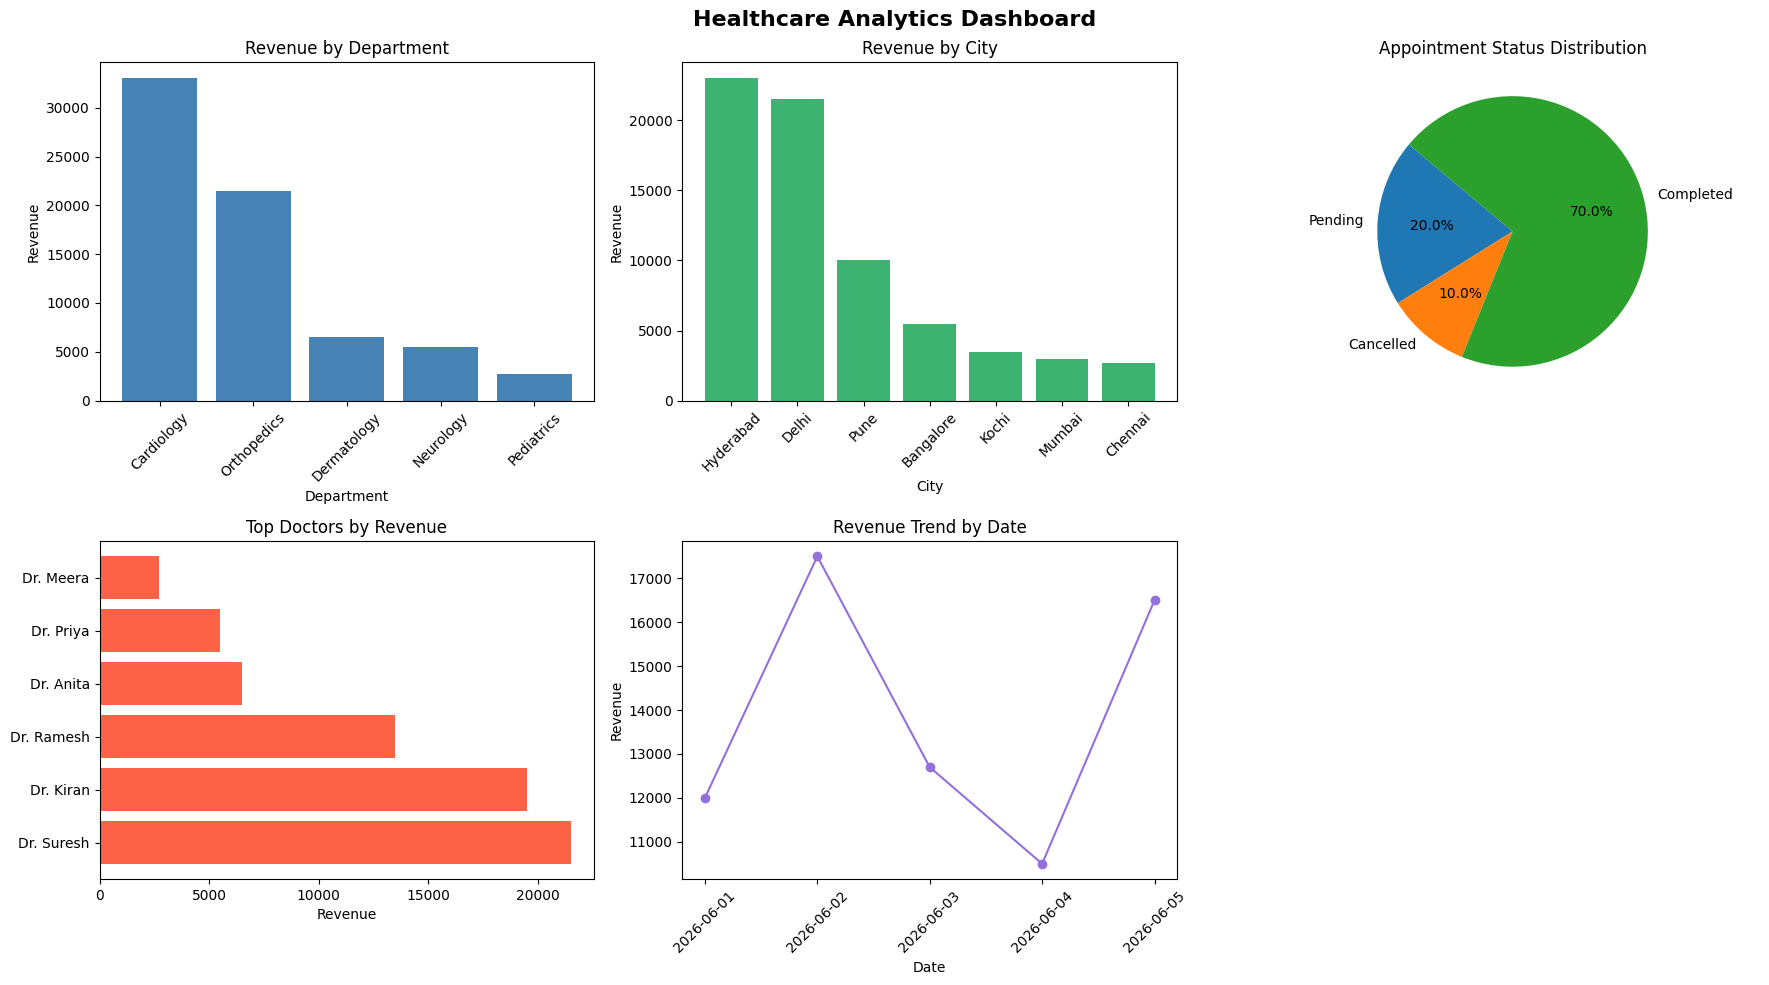

In [0]:
import matplotlib.pyplot as plt
from pyspark.sql.functions import sum as spark_sum, count

dept_rev_pd = df_full.groupBy('department').agg(spark_sum('final_bill').alias('revenue')) \
    .orderBy('revenue', ascending=False).toPandas()

city_rev_pd = df_full.groupBy('patient_city').agg(spark_sum('final_bill').alias('revenue')) \
    .orderBy('revenue', ascending=False).toPandas()

status_pd = df_full.groupBy('status').agg(count('appointment_id').alias('count')).toPandas()

doc_rev_pd = df_full.groupBy('doctor_name').agg(spark_sum('final_bill').alias('revenue')) \
    .orderBy('revenue', ascending=False).toPandas()

date_rev_pd = df_full.groupBy('appointment_date').agg(spark_sum('final_bill').alias('revenue')) \
    .orderBy('appointment_date').toPandas()

fig, axes = plt.subplots(2, 3, figsize=(18, 10))

#38 - Bar chart: Revenue by Department
axes[0,0].bar(dept_rev_pd['department'], dept_rev_pd['revenue'], color='steelblue')
axes[0,0].set_title('Revenue by Department')
axes[0,0].set_xlabel('Department')
axes[0,0].set_ylabel('Revenue')
axes[0,0].tick_params(axis='x', rotation=45)

#39 - Bar chart: Revenue by City
axes[0,1].bar(city_rev_pd['patient_city'], city_rev_pd['revenue'], color='mediumseagreen')
axes[0,1].set_title('Revenue by City')
axes[0,1].set_xlabel('City')
axes[0,1].set_ylabel('Revenue')
axes[0,1].tick_params(axis='x', rotation=45)

#40 - Pie chart: Appointment Status Distribution
axes[0,2].pie(status_pd['count'], labels=status_pd['status'], autopct='%1.1f%%', startangle=140)
axes[0,2].set_title('Appointment Status Distribution')

#41 - Horizontal bar: Top Doctors by Revenue
axes[1,0].barh(doc_rev_pd['doctor_name'], doc_rev_pd['revenue'], color='tomato')
axes[1,0].set_title('Top Doctors by Revenue')
axes[1,0].set_xlabel('Revenue')

#42 - Line chart: Revenue Trend by Date
axes[1,1].plot(date_rev_pd['appointment_date'].astype(str), date_rev_pd['revenue'], marker='o', color='mediumpurple')
axes[1,1].set_title('Revenue Trend by Date')
axes[1,1].set_xlabel('Date')
axes[1,1].set_ylabel('Revenue')
axes[1,1].tick_params(axis='x', rotation=45)

axes[1,2].axis('off')

plt.suptitle('Healthcare Analytics Dashboard', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()


## Part 7: Tables and Views

In [0]:
#43 - Managed Table
spark.sql('DROP TABLE IF EXISTS patients_managed')
df_patients.write.format('delta').mode('overwrite').saveAsTable('patients_managed')
spark.sql('SELECT * FROM patients_managed').show()


+----------+------------+---------+-----------+---+------+----------------+
|patient_id|patient_name|     city|      state|age|gender|insurance_status|
+----------+------------+---------+-----------+---+------+----------------+
|      P101|Rahul Sharma|Hyderabad|  Telangana| 35|  Male|          Active|
|      P102| Priya Reddy|Bangalore|  Karnataka| 29|Female|          Active|
|      P103|  Amit Kumar|   Mumbai|Maharashtra| 42|  Male|        Inactive|
|      P104| Sneha Patel|    Delhi|      Delhi| 31|Female|          Active|
|      P105|  Farhan Ali|  Chennai| Tamil Nadu| 55|  Male|          Active|
|      P106|  Neha Singh|     Pune|Maharashtra| 38|Female|        Inactive|
|      P107| Arjun Verma|Hyderabad|  Telangana| 26|  Male|          Active|
|      P108|  Meera Nair|    Kochi|     Kerala| 48|Female|          Active|
+----------+------------+---------+-----------+---+------+----------------+



In [0]:
#44 - External Table (Unity Catalog compatible)
spark.sql('DROP TABLE IF EXISTS doctors_external')
spark.sql("""
    CREATE TABLE doctors_external
    USING DELTA
    AS SELECT * FROM doctors_view
""")
spark.sql('SELECT * FROM doctors_external').show()


+---------+-----------+-----------+---------+----------------+
|doctor_id|doctor_name| department|     city|consultation_fee|
+---------+-----------+-----------+---------+----------------+
|     D101| Dr. Ramesh| Cardiology|Hyderabad|            1500|
|     D102|  Dr. Priya|  Neurology|Bangalore|            2000|
|     D103|  Dr. Anita|Dermatology|  Chennai|            1000|
|     D104| Dr. Suresh|Orthopedics|   Mumbai|            2500|
|     D105|  Dr. Meera| Pediatrics|    Delhi|            1200|
|     D106|  Dr. Kiran| Cardiology|Hyderabad|            3000|
+---------+-----------+-----------+---------+----------------+



In [0]:
#45 - Temporary View
df_full.createOrReplaceTempView('appointments_temp_view')
spark.sql('SELECT * FROM appointments_temp_view LIMIT 5').show()


+---------+----------+--------------+----------------+-------------+-----------+---------+------------+------------+-----------+---+------+----------------+-----------+-----------+-----------+----------------+----------+-----------------+-----------------+
|doctor_id|patient_id|appointment_id|appointment_date|    diagnosis|bill_amount|   status|patient_name|patient_city|      state|age|gender|insurance_status|doctor_name| department|doctor_city|consultation_fee|final_bill|appointment_month|patient_age_group|
+---------+----------+--------------+----------------+-------------+-----------+---------+------------+------------+-----------+---+------+----------------+-----------+-----------+-----------+----------------+----------+-----------------+-----------------+
|     D101|      P101|         A1001|      2026-06-01|Heart Checkup|       5000|Completed|Rahul Sharma|   Hyderabad|  Telangana| 35|  Male|          Active| Dr. Ramesh| Cardiology|  Hyderabad|            1500|      6500|         

In [0]:
#46 - Global Temporary View (not supported in Serverless - using Temp View instead)
df_full.createOrReplaceTempView('appointments_global_view')
spark.sql('SELECT * FROM appointments_global_view LIMIT 5').show()


+---------+----------+--------------+----------------+-------------+-----------+---------+------------+------------+-----------+---+------+----------------+-----------+-----------+-----------+----------------+----------+-----------------+-----------------+
|doctor_id|patient_id|appointment_id|appointment_date|    diagnosis|bill_amount|   status|patient_name|patient_city|      state|age|gender|insurance_status|doctor_name| department|doctor_city|consultation_fee|final_bill|appointment_month|patient_age_group|
+---------+----------+--------------+----------------+-------------+-----------+---------+------------+------------+-----------+---+------+----------------+-----------+-----------+-----------+----------------+----------+-----------------+-----------------+
|     D101|      P101|         A1001|      2026-06-01|Heart Checkup|       5000|Completed|Rahul Sharma|   Hyderabad|  Telangana| 35|  Male|          Active| Dr. Ramesh| Cardiology|  Hyderabad|            1500|      6500|         

In [0]:
#47 - Compare scope and lifetime of each
print("""
Table/View Comparison:
--------------------------------------------------------------
Managed Table      : Stored in Databricks metastore.
                     Data deleted when table is dropped.
                     Accessible across all sessions.

External Table     : Schema registered in metastore.
                     Data NOT deleted when table is dropped.
                     Points to external storage location.

Temporary View     : Exists only for current Spark session.
                     Dropped automatically when session ends.
                     Not accessible from other notebooks.

Global Temp View   : Available across notebooks in same cluster.
                     Dropped when cluster restarts.
                     Accessed via global_temp.<view_name>.
                     (Not supported in Serverless compute)
--------------------------------------------------------------
""")



Table/View Comparison:
--------------------------------------------------------------
Managed Table      : Stored in Databricks metastore.
                     Data deleted when table is dropped.
                     Accessible across all sessions.

External Table     : Schema registered in metastore.
                     Data NOT deleted when table is dropped.
                     Points to external storage location.

Temporary View     : Exists only for current Spark session.
                     Dropped automatically when session ends.
                     Not accessible from other notebooks.

Global Temp View   : Available across notebooks in same cluster.
                     Dropped when cluster restarts.
                     Accessed via global_temp.<view_name>.
                     (Not supported in Serverless compute)
--------------------------------------------------------------

